# Setup and imports

In [1]:
!pip install torch-geometric -q
#!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cpu.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.4 MB/s eta 0:00:00


In [2]:
# ============================================================================
# SETUP: Instalar dependencias
# ============================================================================



import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# # Configurar dispositivo
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: {device}")

# # Verificar GPU
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name(0)}")
#     print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

In [12]:
# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [15]:
# ============================================================================
# MANTENER SESIÓN ACTIVA (Opcional pero recomendado)
# ============================================================================

from IPython.display import Javascript

display(Javascript('''
    function ClickConnect(){
        console.log("Manteniendo conexión activa...");
        document.querySelector("#top-toolbar > colab-connect-button")?.shadowRoot.querySelector("#connect")?.click();
    }
    setInterval(ClickConnect, 60000);
'''))

print("✅ Auto-click activado para mantener sesión")

<IPython.core.display.Javascript object>

✅ Auto-click activado para mantener sesión


# Load graphs

In [4]:
# ============================================================================
# CARGAR GRAFOS GENERADOS
# ============================================================================

GRAPHS_FILE = '/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/graph_data_DYNAMIC/graphs_dynamic_FIXED_v2.pkl'

print("Cargando grafos...")
start = time.time()

graphs = []

with open(GRAPHS_FILE, 'rb') as f:
    while True:
        try:
            graph = pickle.load(f)
            graphs.append(graph)
        except EOFError:
            break

print(f"✅ Cargados {len(graphs)} grafos en {time.time()-start:.1f}s")

# Verificar primer grafo
g = graphs[0]
print(f"\n📊 Ejemplo de grafo:")
print(f"   Window ID: {g.window_id}")
print(f"   Nodes: {g.num_nodes}")
print(f"   Edges: {g.edge_index.shape[1]}")
print(f"   Node features: {g.x.shape}")
print(f"   Edge features: {g.edge_attr.shape}")
print(f"   Label: {g.y.item()}")

Cargando grafos...
✅ Cargados 710 grafos en 21.1s

📊 Ejemplo de grafo:
   Window ID: 0
   Nodes: 2351
   Edges: 7851
   Node features: torch.Size([2351, 18])
   Edge features: torch.Size([7851, 37])
   Label: 0


# Split train/val/test

In [5]:
# ============================================================================
# SPLIT TEMPORAL
# ============================================================================

# Ordenar por window_id
graphs_sorted = sorted(graphs, key=lambda g: g.window_id)

n = len(graphs_sorted)
train_end = int(0.70 * n)  # 70%
val_end = int(0.85 * n)    # 15%

train_graphs = graphs_sorted[:train_end]
val_graphs = graphs_sorted[train_end:val_end]
test_graphs = graphs_sorted[val_end:]

print("="*70)
print("📊 SPLIT TEMPORAL")
print("="*70)

def print_split_stats(split_name, split_graphs):
    normal = sum(1 for g in split_graphs if g.y.item() == 0)
    attack = sum(1 for g in split_graphs if g.y.item() == 1)

    print(f"\n{split_name}:")
    print(f"   Total:  {len(split_graphs)}")
    print(f"   Normal: {normal} ({normal/len(split_graphs)*100:.1f}%)")
    print(f"   Attack: {attack} ({attack/len(split_graphs)*100:.1f}%)")
    print(f"   Window range: {split_graphs[0].window_id} → {split_graphs[-1].window_id}")

print_split_stats("TRAIN", train_graphs)
print_split_stats("VAL", val_graphs)
print_split_stats("TEST", test_graphs)

# Verificar no-leakage
assert train_graphs[-1].window_id < val_graphs[0].window_id, "❌ Train/Val overlap!"
assert val_graphs[-1].window_id < test_graphs[0].window_id, "❌ Val/Test overlap!"
print("\n✅ No temporal leakage (splits are sequential)")

📊 SPLIT TEMPORAL

TRAIN:
   Total:  496
   Normal: 378 (76.2%)
   Attack: 118 (23.8%)
   Window range: 0 → 1953

VAL:
   Total:  107
   Normal: 42 (39.3%)
   Attack: 65 (60.7%)
   Window range: 1956 → 2164

TEST:
   Total:  107
   Normal: 21 (19.6%)
   Attack: 86 (80.4%)
   Window range: 2165 → 2349

✅ No temporal leakage (splits are sequential)


# Dataloader (batch of graphs)

In [10]:
# ============================================================================
# CELDA 3.5: LIMPIAR GRAFOS (insertar ANTES de crear DataLoaders)
# ============================================================================

print("🧹 Limpiando atributos conflictivos...")

def clean_graph_for_training(graph):
    """
    Elimina atributos personalizados que causan problemas con PyG DataLoader
    Mantiene solo lo necesario para entrenamiento
    """
    # Crear una copia limpia con solo atributos esenciales
    from torch_geometric.data import Data

    clean = Data(
        x=graph.x,
        edge_index=graph.edge_index,
        edge_attr=graph.edge_attr,
        y=graph.y,
        num_nodes=graph.num_nodes
    )

    # Guardar window_id como atributo separado (para tracking)
    clean.window_id = graph.window_id

    return clean

# Limpiar todos los splits
train_graphs_clean = [clean_graph_for_training(g) for g in train_graphs]
val_graphs_clean = [clean_graph_for_training(g) for g in val_graphs]
test_graphs_clean = [clean_graph_for_training(g) for g in test_graphs]

print(f"✅ Grafos limpiados:")
print(f"   Train: {len(train_graphs_clean)}")
print(f"   Val:   {len(val_graphs_clean)}")
print(f"   Test:  {len(test_graphs_clean)}")

# Verificar estructura
g = train_graphs_clean[0]
print(f"\n🔍 Grafo limpio:")
print(f"   Atributos: {list(g.keys())}")
print(f"   x: {g.x.shape}")
print(f"   edge_index: {g.edge_index.shape}")
print(f"   edge_attr: {g.edge_attr.shape}")
print(f"   y: {g.y.shape}")

🧹 Limpiando atributos conflictivos...
✅ Grafos limpiados:
   Train: 496
   Val:   107
   Test:  107

🔍 Grafo limpio:
   Atributos: ['y', 'edge_attr', 'window_id', 'x', 'edge_index', 'num_nodes']
   x: torch.Size([2351, 18])
   edge_index: torch.Size([2, 7851])
   edge_attr: torch.Size([7851, 37])
   y: torch.Size([1])


In [11]:
# ============================================================================
# DATALOADER: Usar grafos limpios
# ============================================================================

BATCH_SIZE = 32

train_loader = DataLoader(train_graphs_clean, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 DataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Probar un batch
sample_batch = next(iter(train_loader))
print(f"\n🔍 Ejemplo de batch:")
print(f"   Batch size: {sample_batch.num_graphs}")
print(f"   Total nodes: {sample_batch.num_nodes}")
print(f"   Total edges: {sample_batch.edge_index.shape[1]}")
print(f"   Node features: {sample_batch.x.shape}")
print(f"   Edge features: {sample_batch.edge_attr.shape}")
print(f"   Labels: {sample_batch.y.shape}")

print("\n✅ DataLoader funcionando correctamente")

📦 DataLoaders creados:
   Train batches: 16
   Val batches:   4
   Test batches:  4

🔍 Ejemplo de batch:
   Batch size: 32
   Total nodes: 55723
   Total edges: 173113
   Node features: torch.Size([55723, 18])
   Edge features: torch.Size([173113, 37])
   Labels: torch.Size([32])

✅ DataLoader funcionando correctamente


# Simple GCN

In [14]:
# ============================================================================
# MODELO 1: GCN Simple (SIN temporal, baseline rápido)
# ============================================================================

class SimpleGCN(nn.Module):
    """
    GCN simple para clasificación de grafos
    Sin LSTM por ahora (solo para verificar que funciona)
    """

    def __init__(self, node_features=18, hidden_dim=64, num_layers=2, dropout=0.3):
        super(SimpleGCN, self).__init__()

        # GCN layers
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GCN encoding
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Global pooling (mean de todos los nodos por grafo)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_dim]

        # Classifier
        out = self.classifier(x)  # [batch_size, 1]

        return out

# Crear modelo
model = SimpleGCN(
    node_features=18,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3
).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo creado: {total_params:,} parámetros")

# Test forward pass
with torch.no_grad():
    sample_batch = sample_batch.to(device)
    output = model(sample_batch)
    print(f"✅ Forward pass OK: {output.shape}")

✅ Modelo creado: 7,489 parámetros
✅ Forward pass OK: torch.Size([32, 1])


## Training

In [16]:
# ============================================================================
# TRAINING
# ============================================================================

# Hyperparámetros
EPOCHS = 20
LR = 0.001
WEIGHT_DECAY = 1e-5

# Class weights (para balancear 62% normal / 38% attack)
pos_weight = torch.tensor([1.6]).to(device)

# Loss y optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Métricas
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': []
}

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch)

        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Guardar predicciones
        probs = torch.sigmoid(out).cpu().detach().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)

    # Métricas
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)
    auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(device)

        out = model(batch)
        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        total_loss += loss.item()

        probs = torch.sigmoid(out).cpu().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)
    auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc, all_preds, all_labels

# TRAINING LOOP
print("="*70)
print("🚀 COMENZANDO ENTRENAMIENTO")
print("="*70)

best_val_auc = 0
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):

    epoch_start = time.time()

    # Train
    train_loss, train_acc, train_auc = train_epoch(model, train_loader, criterion, optimizer)

    # Validation
    val_loss, val_acc, val_auc, _, _ = eval_epoch(model, val_loader, criterion)

    epoch_time = time.time() - epoch_start

    # Guardar métricas
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Print
    print(f"Epoch {epoch+1:02d}/{EPOCHS} ({epoch_time:.1f}s):")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.3f}, AUC={train_auc:.3f}")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.3f}, AUC={val_auc:.3f}")

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"   ✅ Best model saved (AUC={val_auc:.3f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏸️  Early stopping (no improvement for {patience} epochs)")
            break

print(f"\n✅ Training completado. Best Val AUC: {best_val_auc:.3f}")

🚀 COMENZANDO ENTRENAMIENTO


Epoch 01/20 (10.6s):
   Train: Loss=577434780.0000, Acc=0.512, AUC=0.485
   Val:   Loss=1064939896.0000, Acc=0.374, AUC=0.476
   ✅ Best model saved (AUC=0.476)


Epoch 02/20 (8.4s):
   Train: Loss=240185831.5000, Acc=0.508, AUC=0.499
   Val:   Loss=599135598.0000, Acc=0.374, AUC=0.476


Epoch 03/20 (10.0s):
   Train: Loss=131020181.5000, Acc=0.579, AUC=0.525
   Val:   Loss=246365327.0000, Acc=0.374, AUC=0.476


Epoch 04/20 (9.6s):
   Train: Loss=74107460.0000, Acc=0.552, AUC=0.529
   Val:   Loss=165120084.0000, Acc=0.374, AUC=0.476


Epoch 05/20 (9.0s):
   Train: Loss=35457816.8750, Acc=0.496, AUC=0.483
   Val:   Loss=131635736.0000, Acc=0.374, AUC=0.476


Epoch 06/20 (9.1s):
   Train: Loss=17267054.5625, Acc=0.510, AUC=0.465
   Val:   Loss=11911148.9375, Acc=0.374, AUC=0.476

⏸️  Early stopping (no improvement for 5 epochs)

✅ Training completado. Best Val AUC: 0.476


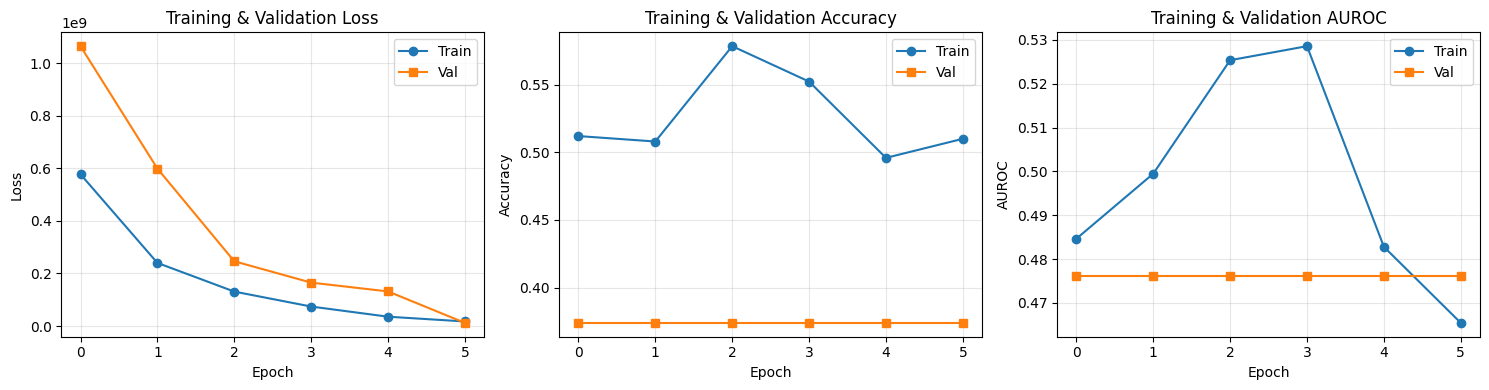

✅ Gráficos guardados: training_curves.png


In [17]:
# ============================================================================
# VISUALIZACIÓN
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUROC
axes[2].plot(history['train_auc'], label='Train', marker='o')
axes[2].plot(history['val_auc'], label='Val', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Training & Validation AUROC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficos guardados: training_curves.png")